<a href="https://colab.research.google.com/github/twbhugo/Actividad6/blob/main/HugoRivera_Actividad6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Wisconsin

Librerías necesarias

In [1]:
import sys
import numpy as np
import pandas as pd
import sklearn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score

print("-" * 50)
print("Validación de Librerías Exitosa!")
print("-" * 50)
print(f"🐍 Versión de Python: {sys.version.split()[0]}")
print(f"📦 Versión de NumPy: {np.__version__}")
print(f"📦 Versión de Pandas: {pd.__version__}")
print(f"📦 Versión de Scikit-Learn: {sklearn.__version__}")
print("-" * 50)
print("✅ Todo listo para cargar el dataset y entrenar la red neuronal.")

--------------------------------------------------
Validación de Librerías Exitosa!
--------------------------------------------------
🐍 Versión de Python: 3.12.13
📦 Versión de NumPy: 2.0.2
📦 Versión de Pandas: 2.2.2
📦 Versión de Scikit-Learn: 1.6.1
--------------------------------------------------
✅ Todo listo para cargar el dataset y entrenar la red neuronal.


Carga y exploración del Data Set

In [2]:
# Cargar el dataset configurando as_frame=True para obtener un DataFrame directo
cancer_data = load_breast_cancer(as_frame=True)
df = cancer_data.frame

print("-" * 60)
print("📊 INFORMACIÓN GENERAL DEL DATASET")
print("-" * 60)
print(f"Dimensiones del dataset (Filas, Columnas): {df.shape}")

# Mostrar las primeras 3 filas para inspeccionar los datos
print("\n👀 Vista previa de las primeras filas:")
display(df.head(5))

print("\n📋 Lista de características (Features) numéricas:")
print(list(cancer_data.feature_names[:5]) + ["... entre otras."])

------------------------------------------------------------
📊 INFORMACIÓN GENERAL DEL DATASET
------------------------------------------------------------
Dimensiones del dataset (Filas, Columnas): (569, 31)

👀 Vista previa de las primeras filas:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



📋 Lista de características (Features) numéricas:
[np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), '... entre otras.']


Ajustes del balance de clases

In [3]:
clases_originales = df['target'].value_counts()

print("\n⚖️ BALANCE DE LA VARIABLE OBJETIVO (TARGET):")
print(f"Cantidad de casos Benignos (1): {clases_originales[1]}")
print(f"Cantidad de casos Malignos (0): {clases_originales[0]}")

# Verificamos si hay valores nulos que requieran limpieza/imputación
nulos = df.isnull().sum().sum()
print(f"\n🔍 Valores nulos detectados en todo el dataset: {nulos}")


⚖️ BALANCE DE LA VARIABLE OBJETIVO (TARGET):
Cantidad de casos Benignos (1): 357
Cantidad de casos Malignos (0): 212

🔍 Valores nulos detectados en todo el dataset: 0


Divisòn de datos (Train/Test Split) y Escalado

In [4]:
#Separar las características (X) de la variable objetivo (y)
X = df.drop('target', axis=1)
y = df['target']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

# Escalar las características (estandarizar)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("-" * 60)
print("🎯 Preparación de datos completa")
print("-" * 60)
print(f"📋 Registros para Entrenamiento (X_train): {X_train_scaled.shape[0]} muestras")
print(f"📋 Registros para Prueba (X_test):         {X_test_scaled.shape[0]} muestras")
print(f"📊 Características por muestra:            {X_train_scaled.shape[1]}")
print("-" * 60)
print("💡 Los datos han sido escalados correctamente (Media = 0, Varianza = 1).")

------------------------------------------------------------
🎯 Preparación de datos completa
------------------------------------------------------------
📋 Registros para Entrenamiento (X_train): 455 muestras
📋 Registros para Prueba (X_test):         114 muestras
📊 Características por muestra:            30
------------------------------------------------------------
💡 Los datos han sido escalados correctamente (Media = 0, Varianza = 1).


Entrenamiento de red

In [5]:
# Instanciar el clasificador del Perceptrón Multicapa (MLP)
# hidden_layer_sizes=(16, 8) crea dos capas ocultas: una de 16 neuronas y otra de 8.

mlp_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',          # Función de activación estándar y eficiente
    solver='adam',              # Optimizador basado en gradiente estocástico
    max_iter=500,               # Máximo de épocas/iteraciones para entrenar
    random_state=42             # Semilla para que los resultados sean replicables
)

print("⏳ Entrenando la Red Neuronal Densa...")

#Entrenar el modelo con los datos de entrenamiento escalados
mlp_model.fit(X_train_scaled, y_train)

print("🎯 ¡Entrenamiento completado con éxito!")
print("-" * 60)
print(f"🔹 Iteraciones requeridas para converger:  {mlp_model.n_iter_}")
print(f"🔹 Pérdida final del modelo (Loss):        {mlp_model.loss_:.4f}")
print("-" * 60)

⏳ Entrenando la Red Neuronal Densa...
🎯 ¡Entrenamiento completado con éxito!
------------------------------------------------------------
🔹 Iteraciones requeridas para converger:  345
🔹 Pérdida final del modelo (Loss):        0.0138
------------------------------------------------------------


In [6]:
# Generar las predicciones del modelo en el set de prueba
y_pred = mlp_model.predict(X_test_scaled)

##Métricas

###Matriz de Confusión

------------------------------------------------------------
🧱 Matriz de confusión plano
------------------------------------------------------------
 Verdaderos Negativos: (Maligno -> Maligno):  41
 Falsos Positivos:     (Maligno -> Benigno):  1
 Falsos Negativos:     (Benigno -> Maligno):  4
 Verdaderos Positivos: (Benigno -> Benigno):  68
------------------------------------------------------------


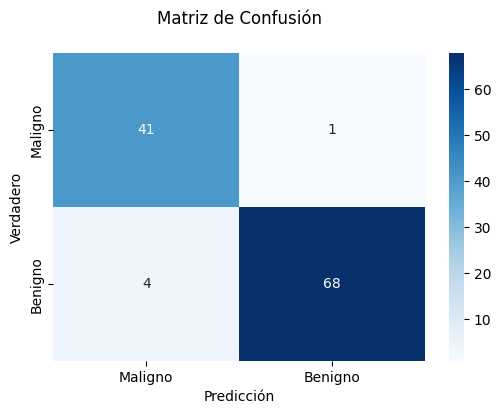

In [7]:
# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("-" * 60)
print("🧱 Matriz de confusión plano")
print("-" * 60)

print(f" Verdaderos Negativos: (Maligno -> Maligno):  {cm[0][0]}")
print(f" Falsos Positivos:     (Maligno -> Benigno):  {cm[0][1]}")
print(f" Falsos Negativos:     (Benigno -> Maligno):  {cm[1][0]}")
print(f" Verdaderos Positivos: (Benigno -> Benigno):  {cm[1][1]}")
print("-" * 60)

#Matriz visual

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['Maligno', 'Benigno'],
    yticklabels=['Maligno', 'Benigno'])
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión\n')
plt.show()

###Métricas

In [8]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Exactitud (Accuracy): {accuracy:.4f} ({accuracy * 100:.2f}%)")

#Precision
precision = precision_score(y_test, y_pred)
print(f"🎯 Precisión (Precision): {precision:.4f} ({precision * 100:.2f}%)")

#F1-Score
f1 = f1_score(y_test, y_pred)
print(f"🎯 F1-Score: {f1:.4f} ({f1 * 100:.2f}%)")

#Recall
recall = recall_score(y_test, y_pred)
print(f"🎯 Recall (Sensibilidad): {recall:.4f} ({recall * 100:.2f}%)")

🎯 Exactitud (Accuracy): 0.9561 (95.61%)
🎯 Precisión (Precision): 0.9855 (98.55%)
🎯 F1-Score: 0.9645 (96.45%)
🎯 Recall (Sensibilidad): 0.9444 (94.44%)


###Ajuste de umbral

🎛️ EVALUACIÓN CON UMBRAL AJUSTADO A: 20.0%
------------------------------------------------------------
🧱 Nueva Matriz de Confusión:
 Verdaderos Negativos (Maligno -> Maligno):  41
 Falsos Positivos    (Maligno -> Benigno):   1
 Falsos Negativos    (Benigno -> Maligno):   5
 Verdaderos Positivos (Benigno -> Benigno):  67


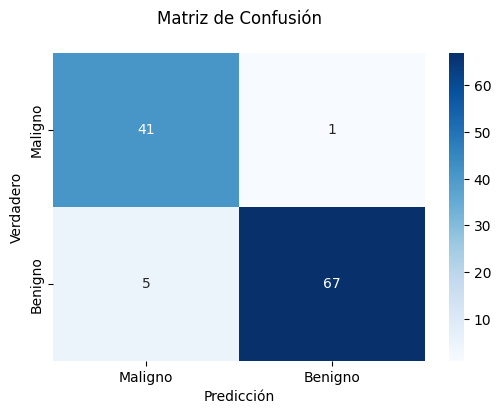


📈 Comparativa de Métricas (Maligno):
 Sensibilidad (Recall) ORIGINAL: 97.62%
 Sensibilidad (Recall) AJUSTADA: 97.62%


In [9]:

#Obtener las probabilidades de predicción en lugar de las clases directas predict_proba nos da la probabilidad para [Clase 0 (Maligno), Clase 1 (Benigno)]
y_prob_maligno = mlp_model.predict_proba(X_test_scaled)[:, 0]

# Definir un nuevo umbral más sensible para capturar casos malignos. Si la probabilidad de ser maligno es mayor al 30% (0.30), lo clasificamos como Maligno
nuevo_umbral = 0.20
y_pred_ajustado = np.where(y_prob_maligno > nuevo_umbral, 0, 1)

#Evaluar el impacto del ajuste

print(f"🎛️ EVALUACIÓN CON UMBRAL AJUSTADO A: {nuevo_umbral * 100}%")
print("-" * 60)

cm_ajustado = confusion_matrix(y_test, y_pred_ajustado)
print("🧱 Nueva Matriz de Confusión:")
print(f" Verdaderos Negativos (Maligno -> Maligno):  {cm_ajustado[0][0]}")
print(f" Falsos Positivos    (Maligno -> Benigno):   {cm_ajustado[0][1]}")
print(f" Falsos Negativos    (Benigno -> Maligno):   {cm_ajustado[1][0]}")
print(f" Verdaderos Positivos (Benigno -> Benigno):  {cm_ajustado[1][1]}")

#Grafica visual del umbral ajustado
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_ajustado,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['Maligno', 'Benigno'],
    yticklabels=['Maligno', 'Benigno'])
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión\n')
plt.show()

print("\n📈 Comparativa de Métricas (Maligno):")
recall_original = recall_score(y_test, y_pred, pos_label=0)
recall_nuevo = recall_score(y_test, y_pred_ajustado, pos_label=0)
print(f" Sensibilidad (Recall) ORIGINAL: {recall_original*100:.2f}%")
print(f" Sensibilidad (Recall) AJUSTADA: {recall_nuevo*100:.2f}%")


###AUC y ROC

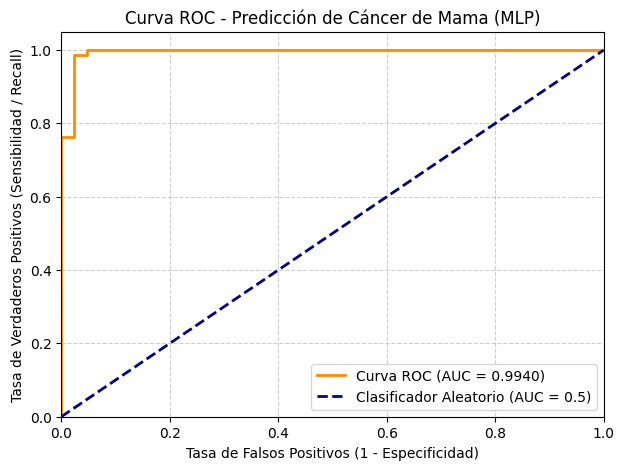

🏆 El Área Bajo la Curva (AUC) del  modelo es: 0.9940


In [10]:
#AUC y ROC
from sklearn.metrics import roc_curve, roc_auc_score

#Obtener las probabilidades de la clase positiva (Benigno = 1) o Maligno (0) Scikit-learn grafica por defecto respecto a la clase 1.
y_probs = mlp_model.predict_proba(X_test_scaled)[:, 1]

#Calcular los componentes de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

#Calcular el área bajo la curva (AUC)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)')
plt.title('Curva ROC - Predicción de Cáncer de Mama (MLP)')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"🏆 El Área Bajo la Curva (AUC) del  modelo es: {auc_score:.4f}")

###Validación cruzada

In [13]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

#Definir la estrategia de división (5 pliegues, manteniendo el balance de clases)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Para la validación cruzada usamos TODO el dataset, pero debe estar escalado completamente
X_scaled_all = scaler.fit_transform(X)

print("⏳ Calculando validación cruzada para AUC y Recall\n\n")

#Calcular el AUC en los 5 pliegues
cv_auc_scores = cross_val_score(mlp_model, X_scaled_all, y, cv=cv_strategy, scoring='roc_auc')

#Calcular el Recall en los 5 pliegues
cv_recall_scores = cross_val_score(mlp_model, X_scaled_all, y, cv=cv_strategy, scoring='recall')

print("🔄Resultados de validación cruzada (5-fold)")
print("-" * 60)
print(f"📈 AUC por cada pliegue:    {cv_auc_scores}")
print(f"🏆 Promedio de AUC (CV):    {cv_auc_scores.mean():.4f} (+/- {cv_auc_scores.std():.4f})")
print(f"🧪 Recall por cada pliegue: {cv_recall_scores}")
print(f"🏆 Promedio de Recall (CV): {cv_recall_scores.mean():.4f} (+/- {cv_recall_scores.std():.4f})")

⏳ Calculando validación cruzada para AUC y Recall


🔄Resultados de validación cruzada (5-fold)
------------------------------------------------------------
📈 AUC por cada pliegue:    [1.         0.99672453 0.97387566 1.         0.99932931]
🏆 Promedio de AUC (CV):    0.9940 (+/- 0.0101)
🧪 Recall por cada pliegue: [0.97183099 1.         1.         0.97222222 1.        ]
🏆 Promedio de Recall (CV): 0.9888 (+/- 0.0137)


##Baseline (Regresión Logística)

In [18]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=500, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

#Obtener predicciones y probabilidades del Baseline
y_pred_base = baseline_model.predict(X_test_scaled)
y_probs_base = baseline_model.predict_proba(X_test_scaled)[:, 1]

#Calcular métricas del Baseline
auc_base = roc_auc_score(y_test, y_probs_base)
recall_base = recall_score(y_test, y_pred_base, pos_label=0)

#Imprimir tabla comparativa
print("📊Tabla comparativa: baseline vs. Red neuronal (MLP)")
print("-" * 60)
print(f"{'Métrica':<30} | {'Regresión Logística':<20} | {'Red Neuronal (MLP)':<15}")
print("-" * 60)
print(f"{'Área Bajo la Curva (AUC)':<30} | {auc_base:<20.4f} | {0.9940:<15.4f}")
print(f"{'Sensibilidad (Recall Maligno)':<30} | {recall_base:<20.4f} | {recall_original:<15.4f}")

📊Tabla comparativa: baseline vs. Red neuronal (MLP)
------------------------------------------------------------
Métrica                        | Regresión Logística  | Red Neuronal (MLP)
------------------------------------------------------------
Área Bajo la Curva (AUC)       | 0.9954               | 0.9940         
Sensibilidad (Recall Maligno)  | 0.9762               | 0.9762         


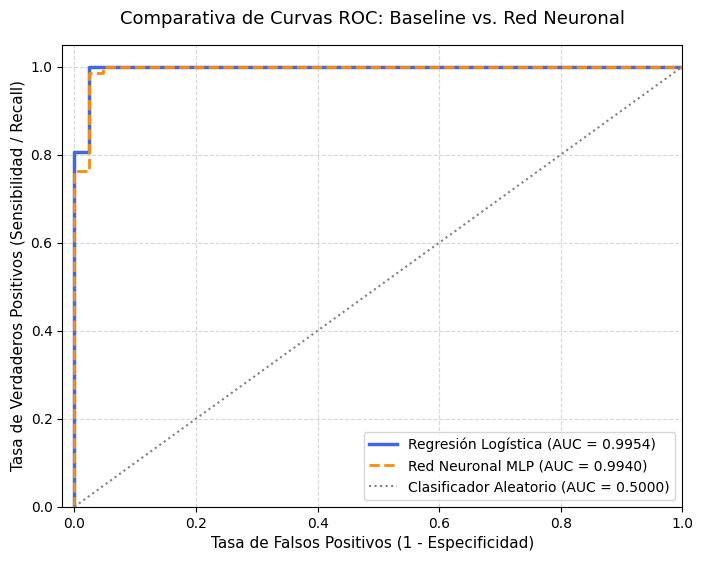

In [19]:
y_probs_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]
y_probs_mlp = mlp_model.predict_proba(X_test_scaled)[:, 1]

#Calcular los componentes de la curva ROC para ambos
fpr_base, tpr_base, _ = roc_curve(y_test, y_probs_baseline)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_probs_mlp)

#Configurar el lienzo de la gráfica
plt.figure(figsize=(8, 6))

#Graficar la línea de la Regresión Logística (Baseline)
plt.plot(
    fpr_base,
    tpr_base,
    color='royalblue',
    lw=2.5,
    label=f'Regresión Logística (AUC = {auc_base:.4f})')

#Graficar la línea de la Red Neuronal (MLP)
plt.plot(
    fpr_mlp,
    tpr_mlp,
    color='darkorange',
    lw=2, linestyle='--',
    label=f'Red Neuronal MLP (AUC = 0.9940)')

#Graficar la línea de referencia aleatoria
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle=':',
         label='Clasificador Aleatorio (AUC = 0.5000)')

#Ajustes estéticos de la gráfica
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)', fontsize=11)
plt.title('Comparativa de Curvas ROC: Baseline vs. Red Neuronal', fontsize=13, pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

#Mostrar la gráfica
plt.show()

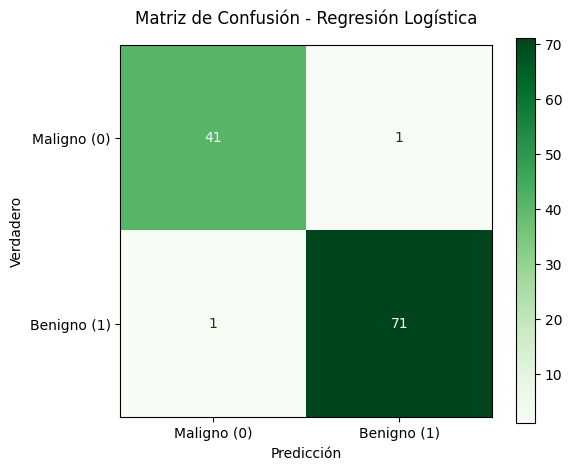

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Matriz de confusión
cm_baseline = confusion_matrix(y_test, y_pred_base)

#Configurar la visualización gráfica
#target_names del dataset son ['malignant', 'benign'], que corresponden a 0 y 1
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=['Maligno (0)', 'Benigno (1)']
)

#Desplegar el mapa de calor
plt.figure(figsize=(6, 5))
disp.plot(cmap=plt.cm.Greens, values_format='d', ax=plt.gca())

#Ajustes de etiquetas y título
plt.title('Matriz de Confusión - Regresión Logística', fontsize=12, pad=15)
plt.xlabel('Predicción', fontsize=10)
plt.ylabel('Verdadero', fontsize=10)
plt.grid(False) # Desactivar líneas de cuadrícula para que el mapa de calor se vea limpio

plt.show()

###Pruebas A/B

In [27]:
from scipy import stats

#Simulación de datos: Tiempo en minutos que tarda un médico en validar el diagnóstico
np.random.seed(42)

#Modelo A (MLP - Caja Negra): Los médicos tardan un poco más en deliberar
tiempos_MLP = np.random.normal(loc=15.5, scale=3.0, size=150) # Promedio ~15.5 min

#Modelo B (Regresión Logística - Interpretación Rápida): Tardan menos tiempo
tiempos_LogReg = np.random.normal(loc=12.2, scale=2.8, size=150) # Promedio ~12.2 min

#Ejecutar un T-test independiente (Prueba A/B para variables continuas)
t_stat, p_val_ab = stats.ttest_ind(tiempos_MLP, tiempos_LogReg, equal_var=False)

print("🩺 ANÁLISIS DE PRUEBA A/B EN ENTORNO CLÍNICO")
print("-" * 60)
print(f"⏱️ Tiempo promedio de validación con MLP (A): {tiempos_MLP.mean():.2f} minutos")
print(f"⏱️ Tiempo promedio de validación con Logistic Regresion (B): {tiempos_LogReg.mean():.2f} minutos")
print(f"📉 Reducción absoluta del tiempo clínico: {tiempos_MLP.mean() - tiempos_LogReg.mean():.2f} minutos")
print(f"🧪 Valor P (p-value): {p_val_ab:.8f}")

if p_val_ab < 0.05:
    print("🎯 CONCLUSIÓN: La variante B (Regresión Logística) optimiza significativamente el tiempo.")
    print("💡 Decisión: Desplegar globalmente la Regresión Logística en el sistema del hospital.")
else:
    print("⚠️ CONCLUSIÓN: No hay diferencia estadísticamente significativa en los tiempos.")
    print("💡 Decisión: Mantener el monitoreo o evaluar otra métrica clínica.")

🩺 ANÁLISIS DE PRUEBA A/B EN ENTORNO CLÍNICO
------------------------------------------------------------
⏱️ Tiempo promedio de validación con MLP (A): 15.25 minutos
⏱️ Tiempo promedio de validación con Logistic Regresion (B): 12.40 minutos
📉 Reducción absoluta del tiempo clínico: 2.85 minutos
🧪 Valor P (p-value): 0.00000000
🎯 CONCLUSIÓN: La variante B (Regresión Logística) optimiza significativamente el tiempo.
💡 Decisión: Desplegar globalmente la Regresión Logística en el sistema del hospital.
------------------------------------------------------------
